# EDA

Посмотрим на наши данные и их распределение

In [68]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

In [10]:
train_images = glob.glob("dataset/train/images/*.jpg")
train_labels = glob.glob("dataset/train/bboxes/*.txt")
test_images = glob.glob("dataset/test/images/*.jpg")
test_labels = glob.glob("dataset/test/bboxes/*.txt")

all_images = train_images + test_images
all_labels = train_labels + test_labels

print("Всего изображений:", len(all_images))
print("Всего txt файлов:", len(all_labels))
print("Всего тренировочных:", len(train_images))
print("Всего тестовых:", len(test_images))

Всего изображений: 4592
Всего txt файлов: 4592
Всего тренировочных: 3942
Всего тестовых: 650


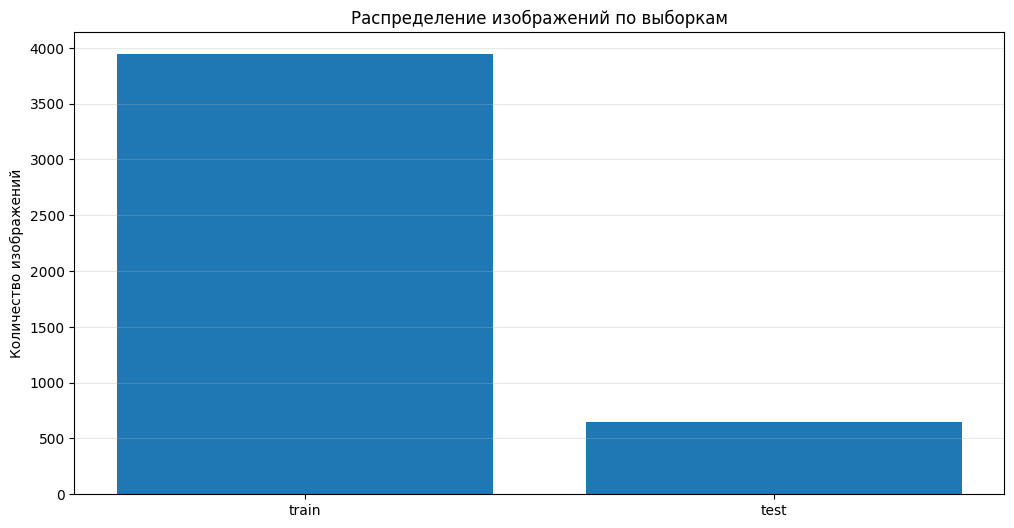

In [76]:
plt.figure(figsize=(12, 6))
bars = plt.bar(['train', 'test'], [len(train_images), len(test_images)])

plt.title('Распределение изображений по выборкам')
plt.ylabel('Количество изображений')
plt.grid(axis='y', alpha=0.3)
plt.show()

Как можно заметить, трениировочная выборка примерно в 6 раз превышает тестовую, что является нормальным распределением выборок. Также можно заметить, что количество изображений и их txt файлов с размметкой совпадает, то есть у каждой картинки есть разметка, что важно при обучении

Посмотрим распределение классов:

In [11]:
all_classes = []
class_counts = {}

for label_path in all_labels:
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 0:
                cls = int(parts[0])
                all_classes.append(cls)
                class_counts[cls] = class_counts.get(cls, 0) + 1

print("Всего объектов:", len(all_classes))

Всего объектов: 5628


Лбъектов больше, чем изображений. Это показывает, что на картинке может быть не один детектируемый объект

In [17]:
sorted_classes = sorted(class_counts.items())

class_names = {
    0: "Bananas",
    1: "Bananas (bag)",
    2: "Blackberries",
    3: "Raspberries",
    4: "Lemons",
    5: "Lemons (bag)",
    6: "Grapes",
    7: "Grapes (bag)",
    8: "Tomatoes",
    9: "Tomatoes (bag)",
    10: "Apples",
    11: "Apples (bag)",
    12: "Chilli",
    13: "Chilli (bag)"
}

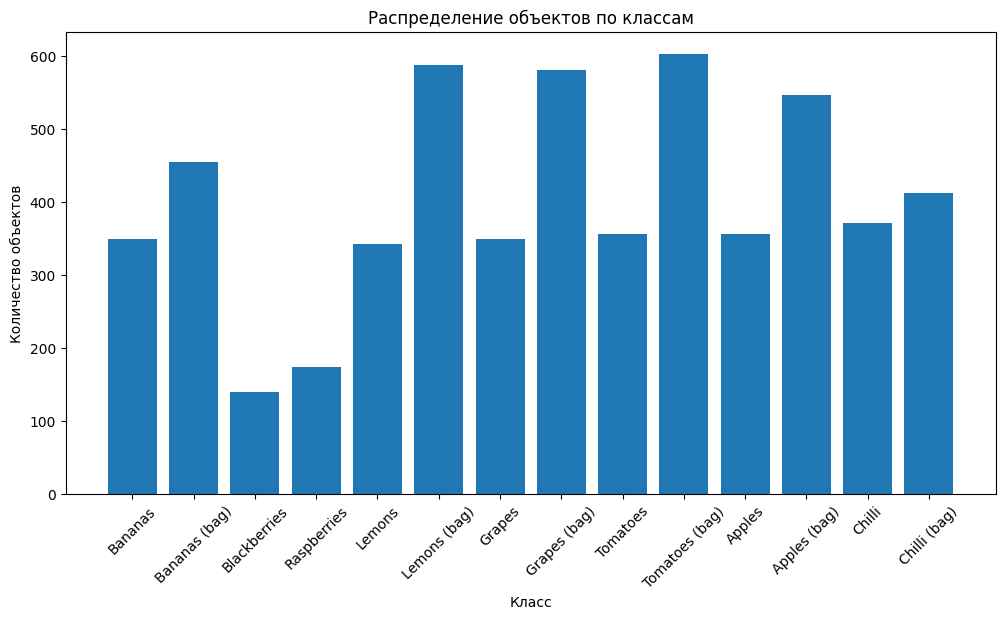

In [20]:
class_labels = [f"{class_names.get(c, f'Class {c}')}" for c, _ in sorted_classes]
class_values = [count for _, count in sorted_classes]

plt.figure(figsize=(12, 6))
plt.bar(class_labels, class_values)
plt.title('Распределение объектов по классам')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.xticks(rotation=45)

plt.show()


Заметим, что модель должна детектить объекты как в пакете, так и без (для нашей бизнес-задачи), но будем считать объект в пакете и без одним классом (так как нам нужен итоговый продукт вне зависимости от наличия пакета). Также уберем лимоны и чилли

In [21]:
class_names_new = {
    0: "Bananas",
    1: "Bananas",
    2: "Blackberries",
    3: "Raspberries",
    # 4: "Lemons",
    # 5: "Lemons (bag)",
    6: "Grapes",
    7: "Grapes",
    8: "Tomatoes",
    9: "Tomatoes",
    10: "Apples",
    11: "Apples",
    # 12: "Chilli",
    # 13: "Chilli (bag)"
}

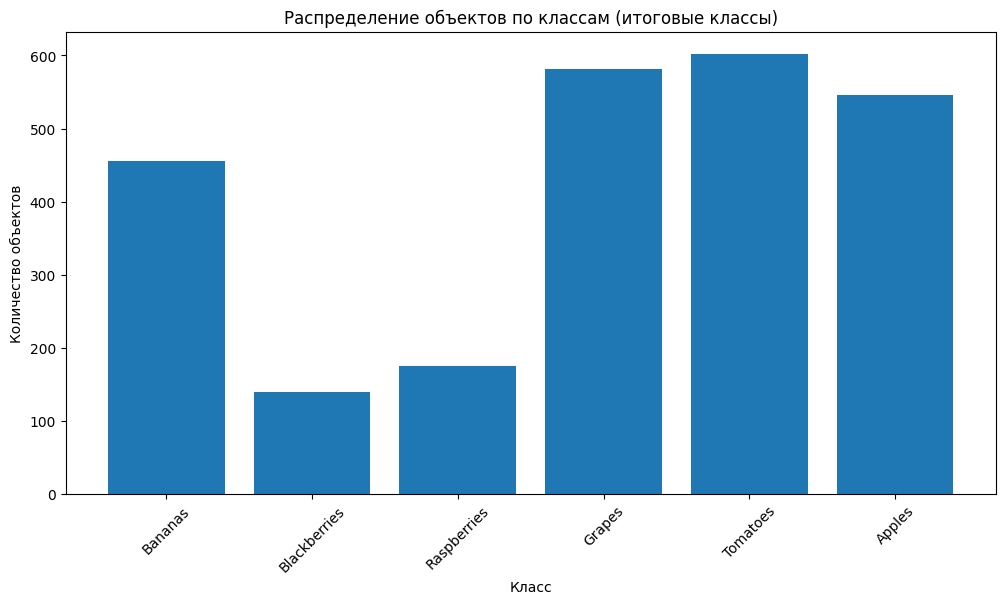

In [23]:
sorted_classes = sorted({k: v for k, v in class_counts.items() if k in class_names_new}.items())

class_labels = [class_names_new[c] for c, _ in sorted_classes]
class_values = [count for _, count in sorted_classes]

plt.figure(figsize=(12, 6))
plt.bar(class_labels, class_values)
plt.title('Распределение объектов по классам (итоговые классы)')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.xticks(rotation=45)

plt.show()

In [57]:
all_boxes = []
all_widths = []
all_heights = []
all_centers_x = []
all_centers_y = []

for label_path in all_labels:
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls, xc, yc, w, h = map(float, parts[:5])
                if cls not in [4, 5, 12, 13]:
                    all_boxes.append([cls, xc, yc, w, h])
                    all_centers_x.append(xc)
                    all_centers_y.append(yc)
                    all_widths.append(w)
                    all_heights.append(h)

print("Всего боксов:", len(all_boxes))

Всего боксов: 3913


Посмотрим распределение центра объектов

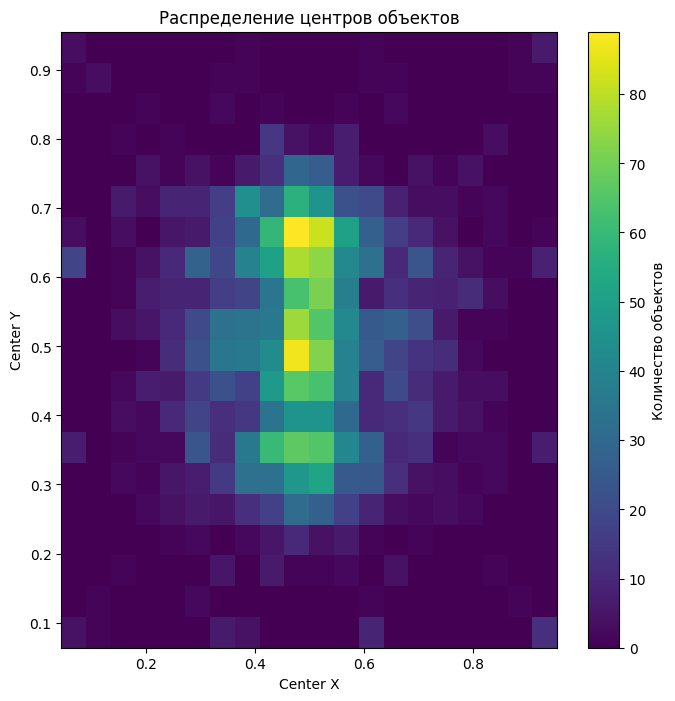

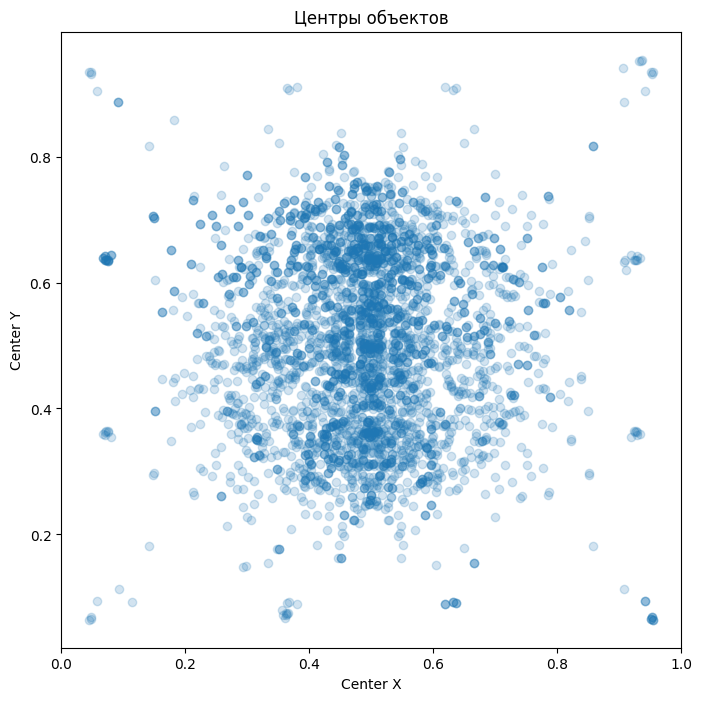

In [58]:
plt.figure(figsize=(8, 8))
plt.hist2d(all_centers_x, all_centers_y, bins=20)
plt.colorbar(label='Количество объектов')
plt.xlabel('Center X')
plt.ylabel('Center Y')
plt.title('Распределение центров объектов')
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(all_centers_x, all_centers_y, alpha=0.2)
plt.xlabel('Center X')
plt.ylabel('Center Y')
plt.title('Центры объектов')
plt.show()

Посмотрим, в каких пропорциях обычно рамки объектов, насколько вообще они пропорциональны друг другу и как много месста занимают объекты на фотографиях

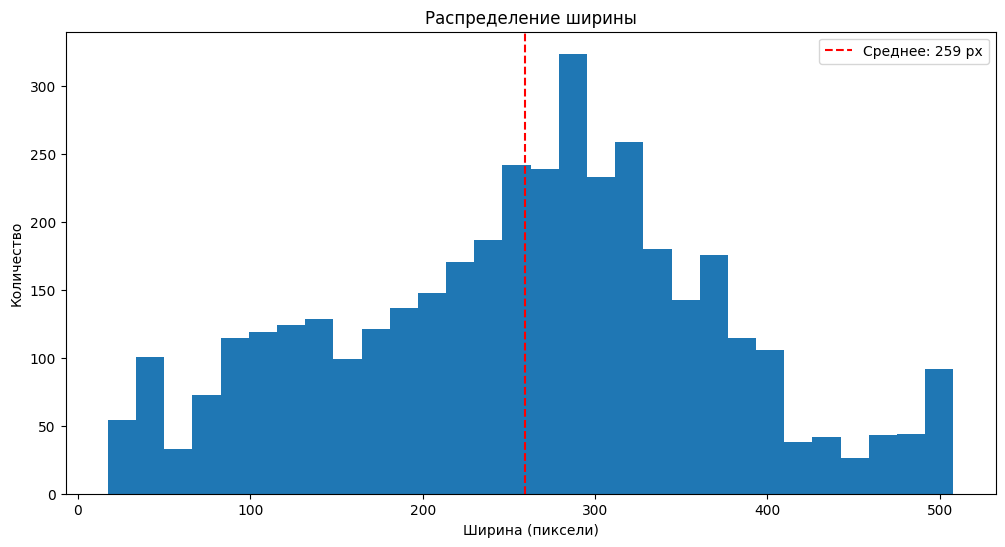

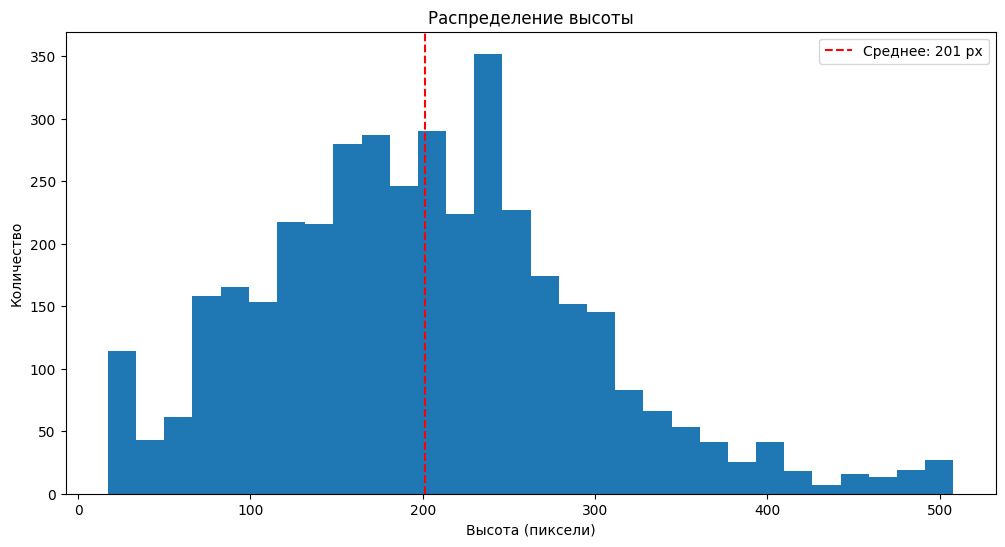

In [82]:
plt.figure(figsize=(12, 6))
plt.hist([w * 512 for w in all_widths], bins=30)
plt.xlabel('Ширина (пиксели)')
plt.ylabel('Количество')
plt.title('Распределение ширины')
plt.axvline(np.mean([w * 512 for w in all_widths]), color='red', linestyle='--', label=f'Среднее: {int(np.mean([w * 512 for w in all_widths]))} px')
plt.legend()

plt.figure(figsize=(12, 6))
plt.hist([h * 512 for h in all_heights], bins=30)
plt.xlabel('Высота (пиксели)')
plt.ylabel('Количество')
plt.title('Распределение высоты')
plt.axvline(np.mean([h * 512 for h in all_heights]), color='red', linestyle='--', label=f'Среднее: {int(np.mean([h * 512 for h in all_heights]))} px')
plt.legend()

plt.show()

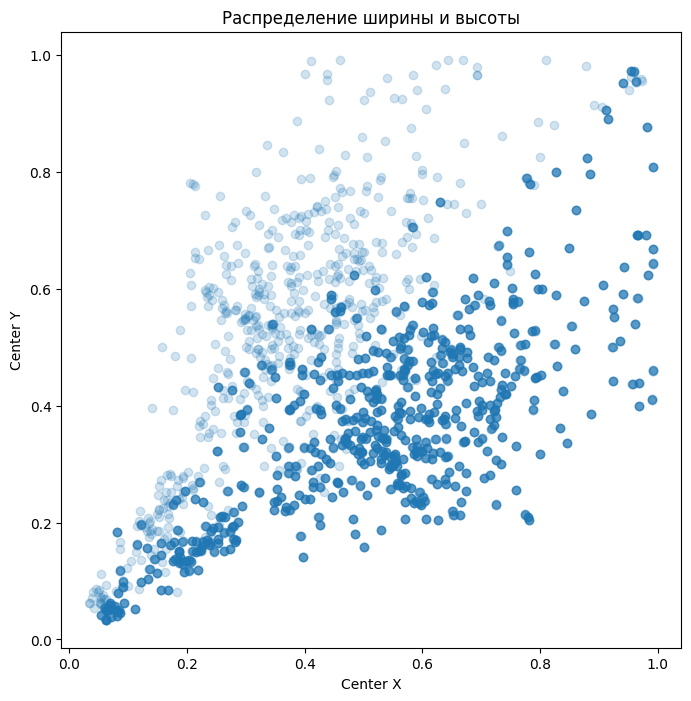

In [60]:
plt.figure(figsize=(8, 8))
plt.scatter(all_widths, all_heights, alpha=0.2)
plt.xlabel('Center X')
plt.ylabel('Center Y')
plt.title('Распределение ширины и высоты')
plt.show()

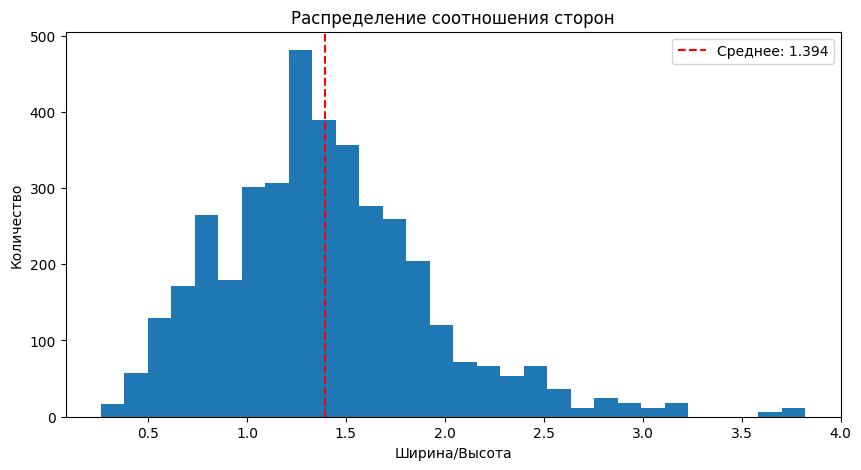

In [61]:
ratios = [w/h for w, h in zip(all_widths, all_heights) if h > 0]

plt.figure(figsize=(10, 5))
plt.hist(ratios, bins=30)
plt.xlabel('Ширина/Высота')
plt.ylabel('Количество')
plt.title('Распределение соотношения сторон')
plt.axvline(np.mean(ratios), color='red', linestyle='--', label=f'Среднее: {np.mean(ratios):.3f}')
plt.legend()
plt.show()

Визуализируем несколько изображений

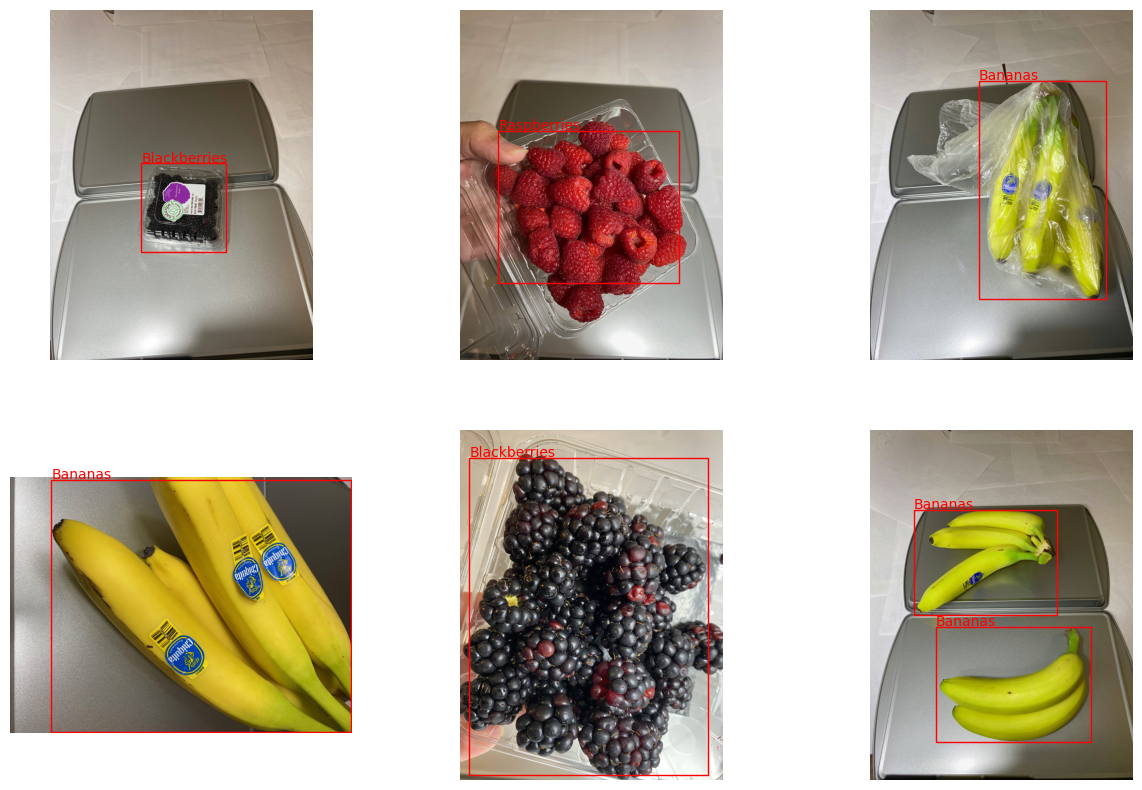

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
possible_images = [img for img in all_images if not "lemon" in img.lower() and not "chilli" in img.lower()]

for i, img_path in enumerate(np.random.choice(possible_images, 6, replace=False)):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    
    txt = img_path.replace("images", "bboxes").replace(".jpg", ".txt")
    if os.path.exists(txt):
        with open(txt) as f:
            for line in f:
                cls, xc, yc, w, h = map(float, line.split())
                x1 = int((xc - w/2) * img.width)
                y1 = int((yc - h/2) * img.height)
                x2 = int((xc + w/2) * img.width)
                y2 = int((yc + h/2) * img.height)
                
                axes[i].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red'))
                axes[i].text(x1, y1-5, class_names_new.get(int(cls), str(int(cls))), color='red')

plt.show()

Посчитаем статистику для классов

In [ ]:
class_stats = {}
for cls, xc, yc, w, h in all_boxes:
    cls = int(cls)
    if cls not in class_stats:
        class_stats[cls] = {'count': 0, 'widths': [], 'heights': []}
    class_stats[cls]['count'] += 1
    class_stats[cls]['widths'].append(w)
    class_stats[cls]['heights'].append(h)

data = []
for cls in sorted(class_stats.keys()):
    stats = class_stats[cls]
    name = class_names_new.get(cls, f"Class {cls}")
    avg_w = np.mean(stats['widths'])
    avg_h = np.mean(stats['heights'])
    
    data.append({'class': cls, 'class_name': name, 'count': stats['count'], 'avg_width': avg_w, 'avg_height': avg_h, 'avg_area': avg_w * avg_h})

stats_df = pd.DataFrame(data)
stats_df

,class,class_name,count,avg_width,avg_height,avg_area
0,0,Bananas,350,0.607569,0.488985,0.297092
1,1,Bananas,455,0.557449,0.461487,0.257255
2,2,Blackberries,140,0.600863,0.513184,0.308353
3,3,Raspberries,175,0.692409,0.589864,0.408428
4,6,Grapes,350,0.553645,0.386438,0.213949
5,7,Grapes,581,0.406708,0.311465,0.126675
6,8,Tomatoes,357,0.594047,0.458082,0.272122
7,9,Tomatoes,602,0.405495,0.290587,0.117831
8,10,Apples,357,0.566951,0.434413,0.246291
9,11,Apples,546,0.404403,0.317032,0.128209


Посчитаем статистику без учета деления на фрукты/овощи в пакете и без 

In [75]:
stats_df.groupby('class_name').agg({'class': lambda x: list(x), 'count': 'sum', 'avg_width': 'mean', 'avg_height': 'mean', 'avg_area': 'mean'}).reset_index()

,class_name,class,count,avg_width,avg_height,avg_area
0,Apples,"[10, 11]",903,0.485677,0.375723,0.187250
1,Bananas,"[0, 1]",805,0.582509,0.475236,0.277174
2,Blackberries,[2],140,0.600863,0.513184,0.308353
3,Grapes,"[6, 7]",931,0.480177,0.348951,0.170312
4,Raspberries,[3],175,0.692409,0.589864,0.408428
5,Tomatoes,"[8, 9]",959,0.499771,0.374334,0.194977
